# 04. 各モデルの性能比較・アンサンブル — 2026-03-08

## リクルート飲食店来客数予測コンペティション

**目的**: 03-1〜03-4のチューニング済みモデルを横断比較し、最適なアンサンブル構成を決定する。

### 前提条件（02で確定済み）
- 学習データ期間、NaN処理、Rolling手法は02で検証・確定済み
- 各モデルのOptunaチューニングは03-1〜03-4で実施済み

### 本ノートブックの構成
1. データ・モデル結果の読み込み
2. 単体モデル性能の横断比較
3. セグメント別の得意・不得意分析
4. 特徴量重要度の横断比較
5. Ablation Study（カテゴリ別寄与度）
6. アンサンブル戦略の検証
7. 最終結果まとめ

---
## 1. データ・モデル結果の読み込み

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
from pathlib import Path
from itertools import combinations
warnings.filterwarnings('ignore')

import lightgbm as lgb
from sklearn.metrics import mean_squared_error

%matplotlib inline
plt.rcParams['font.family'] = 'MS Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.size'] = 12
plt.rcParams['figure.facecolor'] = 'white'

SEED = 42
INTERMEDIATE_DIR = Path('./intermediate')

def rmsle(y_true, y_pred):
    y_pred = np.clip(y_pred, 0, None)
    return np.sqrt(mean_squared_error(np.log1p(y_true), np.log1p(y_pred)))

# 02の中間データ
with open(INTERMEDIATE_DIR / '02_feature_design.pkl', 'rb') as f:
    prev_02 = pickle.load(f)

train_df = prev_02['train_features']
valid_df = prev_02['valid_features']
all_features = prev_02['feature_columns']['all_features']
settings = prev_02['confirmed_settings']

# 学習データ期間フィルタ適用
train_df = train_df[train_df['visit_date'] >= settings['best_train_start']].copy()

# 03-1〜03-4の結果
results = {}
model_files = {
    'LightGBM': '03-1_lgbm_results.pkl',
    'XGBoost': '03-2_xgb_results.pkl',
    'RandomForest': '03-3_rf_results.pkl',
    'CatBoost': '03-4_catboost_results.pkl',
}
for name, fname in model_files.items():
    with open(INTERMEDIATE_DIR / fname, 'rb') as f:
        results[name] = pickle.load(f)

print('=== 読み込み完了 ===')
print(f'学習データ: {train_df.shape}, 検証データ: {valid_df.shape}')
print(f'特徴量: {len(all_features)}個')
print(f'\n=== 確定済み前提条件（02で決定）===')
for k, v in settings.items():
    print(f'  {k}: {v}')

=== 読み込み完了 ===
学習データ: (222073, 60), 検証データ: (30035, 60)
特徴量: 53個

=== 確定済み前提条件（02で決定）===
  best_train_period: 直近15ヶ月
  best_train_start: 2015-12-12
  best_train_period_days: 456
  best_nan_strategy: NaN(デフォルト)
  best_rolling_config: 現行のみ


---
## 2. 単体モデル性能の横断比較

In [2]:
# スコア一覧テーブル（デフォルト vs チューニング済み）
summary_rows = []
for name, r in results.items():
    row = {
        'モデル': name,
        'デフォルト RMSLE': r['score_single'],
        'チューニング後 RMSLE': r.get('tuned_score', r['score_single']),
        'CV平均 RMSLE': r['cv_mean'],
        'CV標準偏差': r['cv_std'],
    }
    row['改善幅'] = row['デフォルト RMSLE'] - row['チューニング後 RMSLE']
    summary_rows.append(row)

summary = pd.DataFrame(summary_rows).sort_values('チューニング後 RMSLE')
print('=== 全モデルスコア比較 ===')
print(summary.to_string(index=False))

=== 全モデルスコア比較 ===
         モデル  デフォルト RMSLE  チューニング後 RMSLE  CV平均 RMSLE   CV標準偏差       改善幅
     XGBoost     0.489719       0.489165    0.501959 0.013779  0.000554
    CatBoost     0.497214       0.494415    0.502405 0.012881  0.002800
RandomForest     0.512153       0.506983    0.510572 0.012721  0.005170
    LightGBM     0.502534       0.516644    0.500875 0.013003 -0.014110


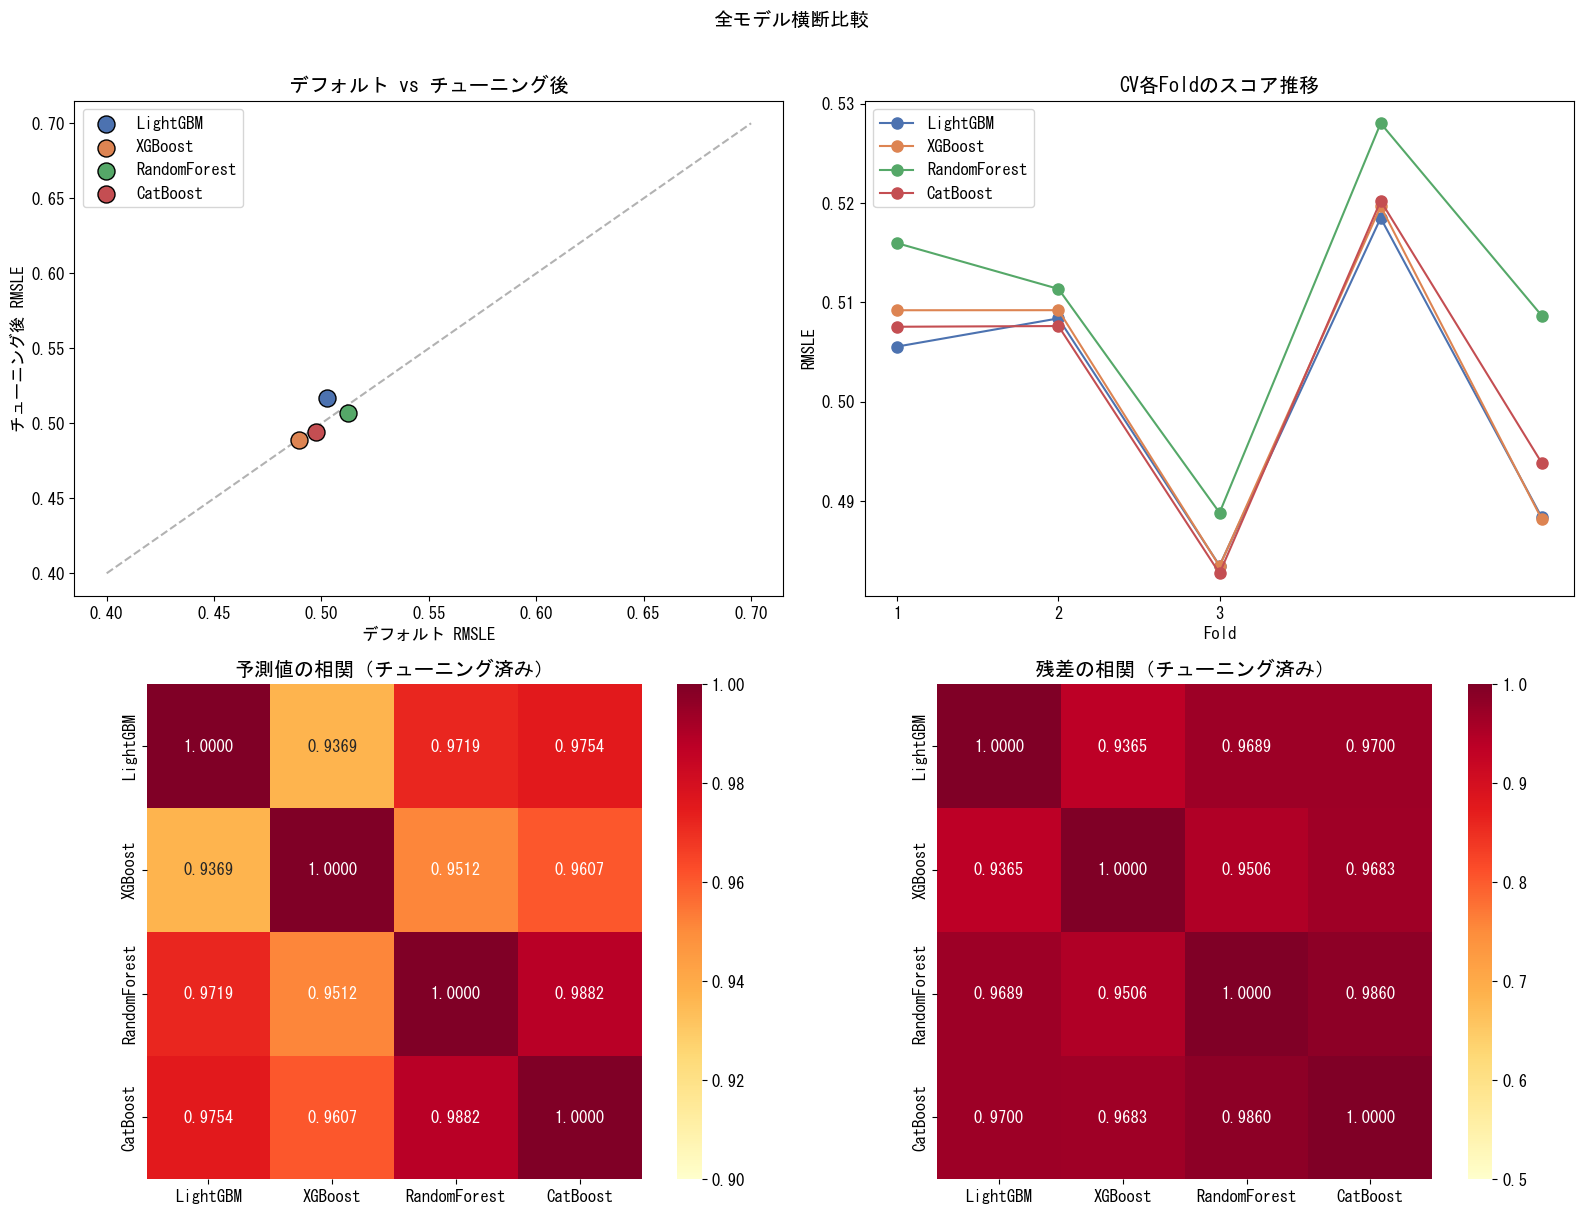

In [3]:
model_colors = {'LightGBM': '#4C72B0', 'XGBoost': '#DD8452',
                'RandomForest': '#55A868', 'CatBoost': '#C44E52'}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# (1) デフォルト vs チューニング後
for name, r in results.items():
    tuned = r.get('tuned_score', r['score_single'])
    axes[0, 0].scatter(r['score_single'], tuned, s=150, c=model_colors[name],
                       label=name, zorder=5, edgecolors='black')
axes[0, 0].plot([0.4, 0.7], [0.4, 0.7], 'k--', alpha=0.3)
axes[0, 0].set_xlabel('デフォルト RMSLE')
axes[0, 0].set_ylabel('チューニング後 RMSLE')
axes[0, 0].set_title('デフォルト vs チューニング後')
axes[0, 0].legend()

# (2) CV各Foldのスコア
for name, r in results.items():
    axes[0, 1].plot(range(1, len(r['cv_scores'])+1), r['cv_scores'], 'o-',
                    color=model_colors[name], label=name, markersize=8)
axes[0, 1].set_xlabel('Fold')
axes[0, 1].set_ylabel('RMSLE')
axes[0, 1].set_title('CV各Foldのスコア推移')
axes[0, 1].legend()
axes[0, 1].set_xticks([1, 2, 3])

# (3) 予測値の相関（チューニング済み）
pred_df = pd.DataFrame({
    name: r.get('tuned_pred', r['valid_pred']) for name, r in results.items()
})
sns.heatmap(pred_df.corr(), annot=True, fmt='.4f', cmap='YlOrRd',
            ax=axes[1, 0], square=True, vmin=0.9, vmax=1.0)
axes[1, 0].set_title('予測値の相関（チューニング済み）')

# (4) 残差の相関（チューニング済み）
resid_df = pd.DataFrame({
    name: r.get('tuned_residuals', r['residuals']) for name, r in results.items()
})
sns.heatmap(resid_df.corr(), annot=True, fmt='.4f', cmap='YlOrRd',
            ax=axes[1, 1], square=True, vmin=0.5, vmax=1.0)
axes[1, 1].set_title('残差の相関（チューニング済み）')

plt.suptitle('全モデル横断比較', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## 3. セグメント別の得意・不得意分析

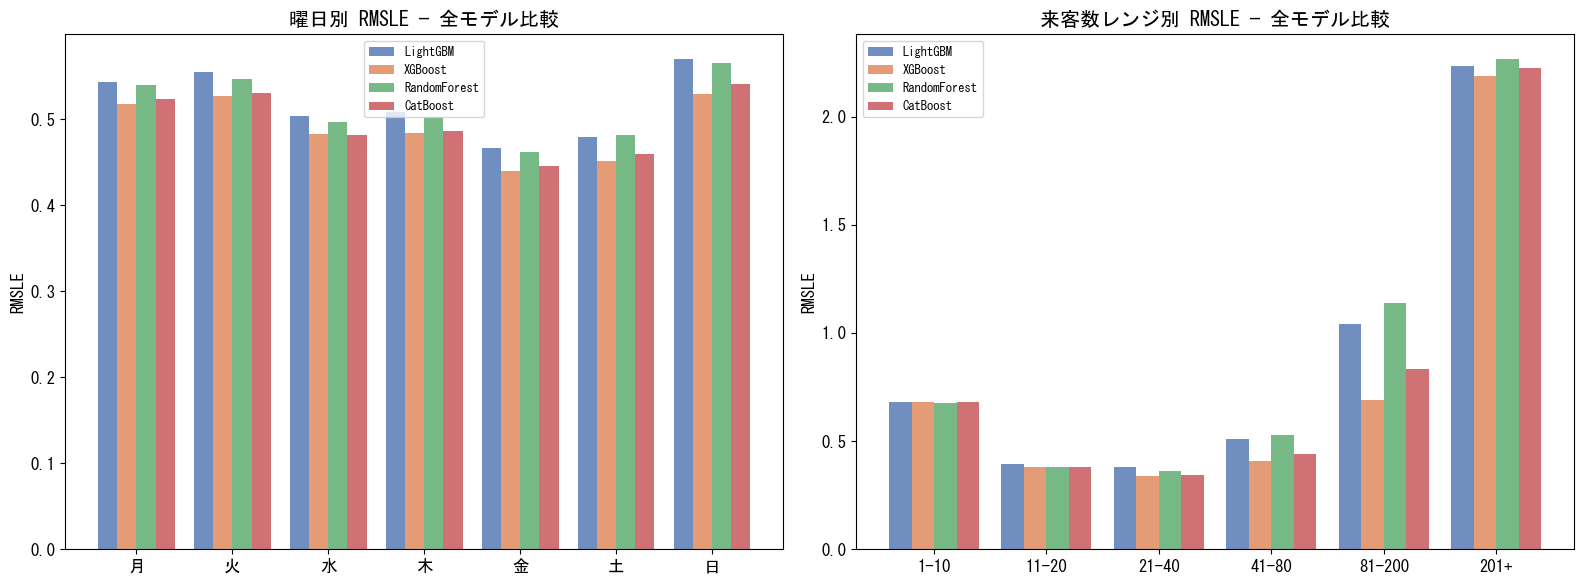

In [4]:
actual = valid_df['visitors'].values
dow_names = ['月', '火', '水', '木', '金', '土', '日']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 曜日別
x = np.arange(7)
width = 0.2
for i, (name, r) in enumerate(results.items()):
    preds = r.get('tuned_pred', r['valid_pred'])
    dow_scores = [rmsle(actual[valid_df['dow'].values == d], preds[valid_df['dow'].values == d]) for d in range(7)]
    axes[0].bar(x + i * width, dow_scores, width, label=name, color=model_colors[name], alpha=0.8)
axes[0].set_xticks(x + width * 1.5)
axes[0].set_xticklabels(dow_names)
axes[0].set_ylabel('RMSLE')
axes[0].set_title('曜日別 RMSLE — 全モデル比較')
axes[0].legend(fontsize=9)

# 来客数レンジ別
bins = [0, 10, 20, 40, 80, 200, 1000]
labels = ['1-10', '11-20', '21-40', '41-80', '81-200', '201+']
visitor_range = pd.cut(actual, bins=bins, labels=labels)
x2 = np.arange(len(labels))
for i, (name, r) in enumerate(results.items()):
    preds = r.get('tuned_pred', r['valid_pred'])
    range_scores = [rmsle(actual[visitor_range == l], preds[visitor_range == l])
                    if (visitor_range == l).sum() > 0 else np.nan for l in labels]
    axes[1].bar(x2 + i * width, range_scores, width, label=name, color=model_colors[name], alpha=0.8)
axes[1].set_xticks(x2 + width * 1.5)
axes[1].set_xticklabels(labels)
axes[1].set_ylabel('RMSLE')
axes[1].set_title('来客数レンジ別 RMSLE — 全モデル比較')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## 4. 特徴量重要度の横断比較

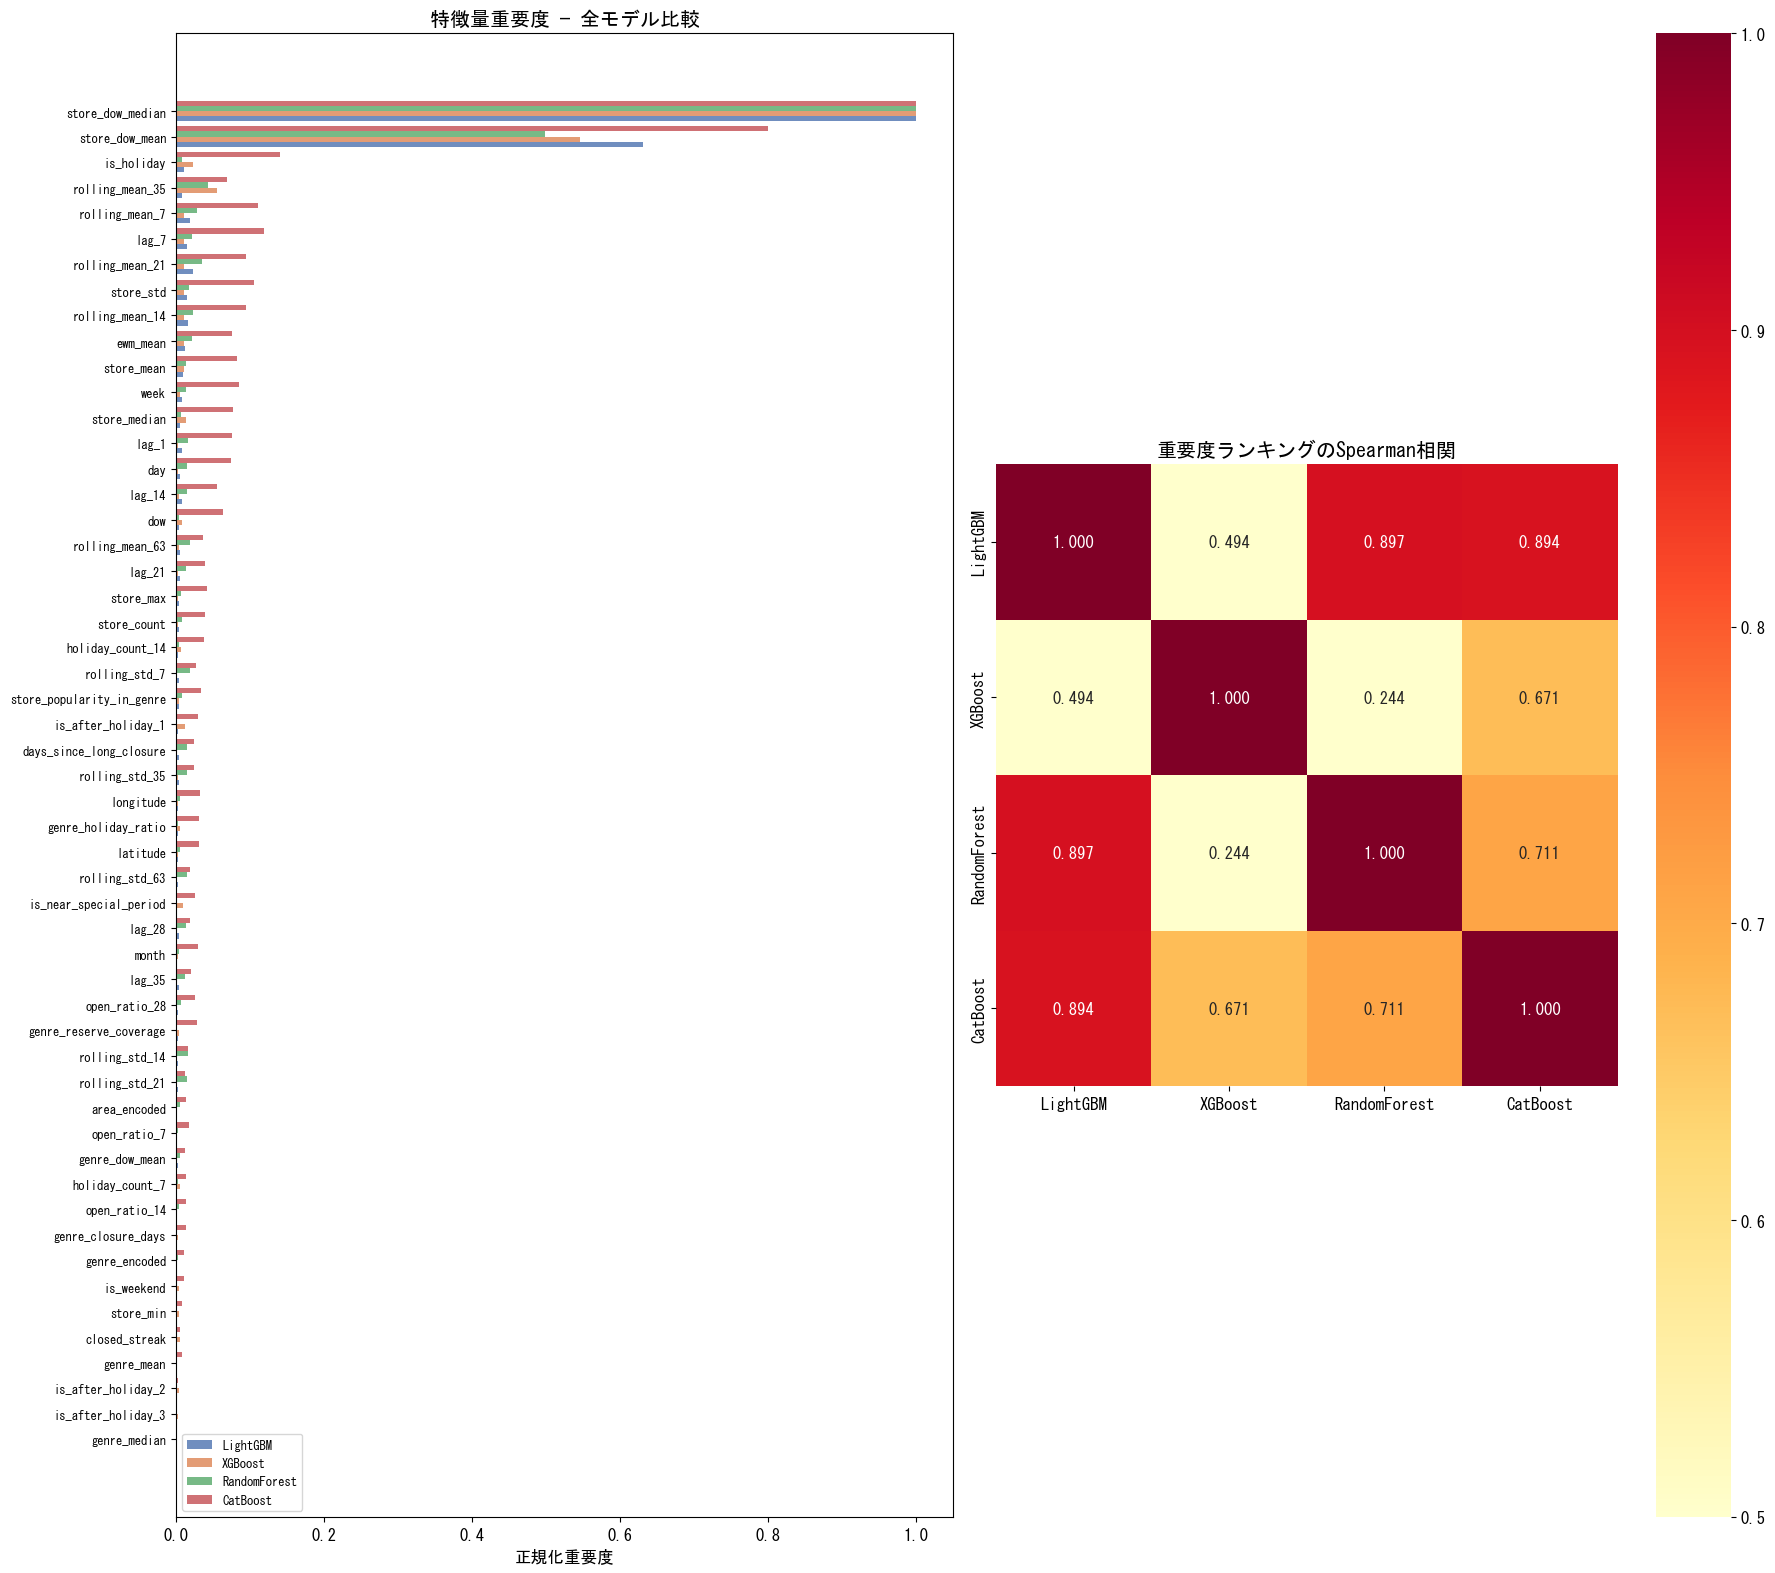


=== モデル横断 重要度 Top 10 ===
  store_dow_median               平均=1.000  (1.00 | 1.00 | 1.00 | 1.00)
  store_dow_mean                 平均=0.619  (0.63 | 0.55 | 0.50 | 0.80)
  is_holiday                     平均=0.046  (0.01 | 0.02 | 0.01 | 0.14)
  rolling_mean_35                平均=0.044  (0.01 | 0.06 | 0.04 | 0.07)
  rolling_mean_7                 平均=0.042  (0.02 | 0.01 | 0.03 | 0.11)
  lag_7                          平均=0.042  (0.01 | 0.01 | 0.02 | 0.12)
  rolling_mean_21                平均=0.041  (0.02 | 0.01 | 0.04 | 0.09)
  store_std                      平均=0.037  (0.01 | 0.01 | 0.02 | 0.11)
  rolling_mean_14                平均=0.036  (0.02 | 0.01 | 0.02 | 0.09)
  ewm_mean                       平均=0.030  (0.01 | 0.01 | 0.02 | 0.08)


In [5]:
# 各モデルの特徴量重要度を正規化して比較
importance_all = pd.DataFrame({'feature': all_features})
for name, r in results.items():
    imp = r['feature_importance'].set_index('feature')['importance']
    imp_norm = (imp - imp.min()) / (imp.max() - imp.min())
    importance_all[name] = importance_all['feature'].map(imp_norm)

importance_all['平均重要度'] = importance_all[list(results.keys())].mean(axis=1)
importance_all = importance_all.sort_values('平均重要度', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(18, max(10, len(all_features) * 0.3)))

y_pos = np.arange(len(all_features))
bar_width = 0.2
for i, name in enumerate(results.keys()):
    axes[0].barh(y_pos + i * bar_width, importance_all[name].values,
                 bar_width, label=name, color=model_colors[name], alpha=0.8)
axes[0].set_yticks(y_pos + bar_width * 1.5)
axes[0].set_yticklabels(importance_all['feature'].values, fontsize=9)
axes[0].set_xlabel('正規化重要度')
axes[0].set_title('特徴量重要度 — 全モデル比較')
axes[0].legend(fontsize=9)

# ランキング相関
rank_df = pd.DataFrame({name: importance_all[name].rank(ascending=False) for name in results})
sns.heatmap(rank_df.corr(method='spearman'), annot=True, fmt='.3f', cmap='YlOrRd',
            ax=axes[1], square=True, vmin=0.5, vmax=1.0)
axes[1].set_title('重要度ランキングのSpearman相関')

plt.tight_layout()
plt.show()

print('\n=== モデル横断 重要度 Top 10 ===')
for _, row in importance_all.tail(10).iloc[::-1].iterrows():
    vals = ' | '.join([f'{row[n]:.2f}' for n in results.keys()])
    print(f'  {row["feature"]:30s} 平均={row["平均重要度"]:.3f}  ({vals})')

---
## 5. Ablation Study（カテゴリ別寄与度）

特徴量カテゴリを1つずつ除外し、スコアの悪化幅でカテゴリの寄与度を評価する。

In [6]:
def categorize_feature(name):
    if name.startswith('rolling_') or name.startswith('ewm_'):
        return 'Rolling統計量'
    elif name.startswith('lag_'):
        return 'ラグ特徴量'
    elif name.startswith(('open_ratio_', 'closed_streak', 'days_since_')):
        return '休業パターン'
    elif name.startswith(('is_after_holiday_', 'holiday_count_', 'is_near_special')):
        return '祝日前後'
    elif name.startswith('store_'):
        return '店舗統計量'
    elif name.startswith('genre_'):
        return 'ジャンル'
    else:
        return '時間/店舗属性'

categories = {}
for f in all_features:
    cat = categorize_feature(f)
    categories.setdefault(cat, []).append(f)

# LightGBMのチューニング済みパラメータで検証
lgb_params = results['LightGBM'].get('tuned_params', results['LightGBM']['params'])
y_train_log = np.log1p(train_df['visitors'])
y_valid_log = np.log1p(valid_df['visitors'])

base_score = results['LightGBM'].get('tuned_score', results['LightGBM']['score_single'])

ablation_results = {}
for cat_name, cat_features in categories.items():
    remaining = [f for f in all_features if f not in cat_features]
    dtr = lgb.Dataset(train_df[remaining], label=y_train_log)
    dva = lgb.Dataset(valid_df[remaining], label=y_valid_log, reference=dtr)
    m = lgb.train(lgb_params, dtr, num_boost_round=2000,
                  valid_sets=[dva], callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(0)])
    p = np.expm1(m.predict(valid_df[remaining]))
    s = rmsle(valid_df['visitors'], p)
    degradation = s - base_score
    ablation_results[cat_name] = {'score': s, 'degradation': degradation, 'n_features': len(cat_features)}
    print(f'{cat_name:14s} を除外: RMSLE={s:.5f} (悪化幅: +{degradation:.5f}, 除外数: {len(cat_features)})')

print(f'\nベースライン: RMSLE={base_score:.5f}')

時間/店舗属性        を除外: RMSLE=0.52139 (悪化幅: +0.00475, 除外数: 9)
ジャンル           を除外: RMSLE=0.51621 (悪化幅: +-0.00043, 除外数: 7)
店舗統計量          を除外: RMSLE=0.50748 (悪化幅: +-0.00917, 除外数: 9)
Rolling統計量     を除外: RMSLE=0.52776 (悪化幅: +0.01112, 除外数: 11)
ラグ特徴量          を除外: RMSLE=0.51896 (悪化幅: +0.00232, 除外数: 6)
休業パターン         を除外: RMSLE=0.51588 (悪化幅: +-0.00077, 除外数: 5)
祝日前後           を除外: RMSLE=0.51552 (悪化幅: +-0.00113, 除外数: 6)

ベースライン: RMSLE=0.51664


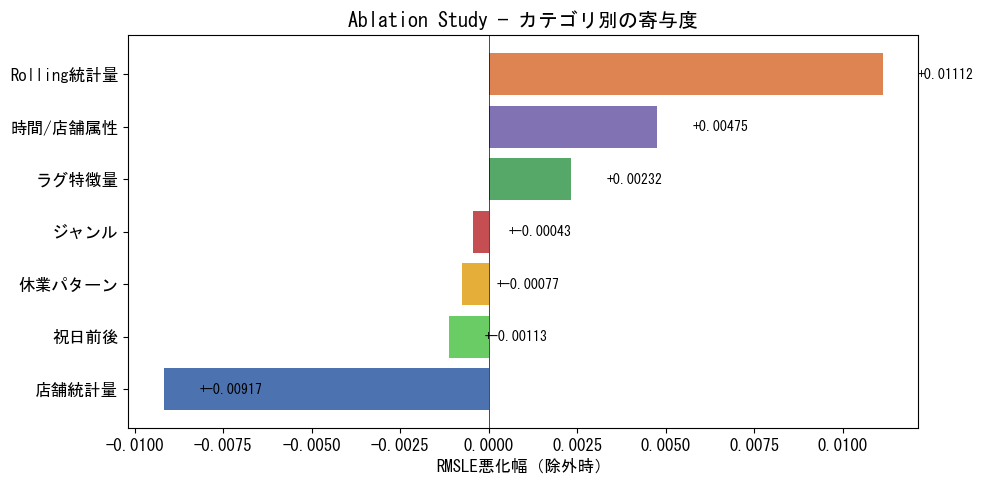

In [7]:
color_map_cat = {
    'Rolling統計量': '#DD8452', 'ラグ特徴量': '#55A868',
    '店舗統計量': '#4C72B0', 'ジャンル': '#C44E52', '時間/店舗属性': '#8172B3',
    '休業パターン': '#E5AE38', '祝日前後': '#6ACC65'
}

fig, ax = plt.subplots(figsize=(10, 5))
cat_names = sorted(ablation_results, key=lambda k: ablation_results[k]['degradation'])
degradations = [ablation_results[c]['degradation'] for c in cat_names]
colors = [color_map_cat.get(c, 'gray') for c in cat_names]

bars = ax.barh(cat_names, degradations, color=colors)
for bar, val in zip(bars, degradations):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'+{val:.5f}', va='center', fontsize=10)
ax.set_xlabel('RMSLE悪化幅（除外時）')
ax.set_title('Ablation Study — カテゴリ別の寄与度')
ax.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

---
## 6. アンサンブル戦略の検証

In [8]:
# チューニング済み予測値を使用
tuned_preds = {
    name: r.get('tuned_pred', r['valid_pred']) for name, r in results.items()
}

# 全組み合わせの単純平均
model_list = list(tuned_preds.keys())
ensemble_results = []

for r_size in range(2, len(model_list) + 1):
    for combo in combinations(model_list, r_size):
        avg_pred = np.mean([tuned_preds[n] for n in combo], axis=0)
        s = rmsle(actual, avg_pred)
        ensemble_results.append({
            '組み合わせ': ' + '.join([n[:3] for n in combo]),
            'モデル数': len(combo),
            'RMSLE': s,
            'models': combo,
        })

ens_df = pd.DataFrame(ensemble_results).sort_values('RMSLE')
print('=== アンサンブル結果（単純平均、上位10） ===')
print(ens_df.head(10)[['組み合わせ', 'モデル数', 'RMSLE']].to_string(index=False))

=== アンサンブル結果（単純平均、上位10） ===
                組み合わせ  モデル数    RMSLE
            XGB + Cat     2 0.487386
      XGB + Ran + Cat     3 0.488238
            XGB + Ran     2 0.489151
      Lig + XGB + Cat     3 0.489479
Lig + XGB + Ran + Cat     4 0.489872
      Lig + XGB + Ran     3 0.490820
            Lig + XGB     2 0.491546
            Ran + Cat     2 0.498724
            Lig + Cat     2 0.500072
      Lig + Ran + Cat     3 0.500916


In [9]:
# 重み付きアンサンブルの最適化（Optuna）
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective_weight(trial):
    weights = {}
    for name in model_list:
        weights[name] = trial.suggest_float(f'w_{name}', 0.0, 1.0)
    total = sum(weights.values())
    if total == 0:
        return 999
    weighted_pred = sum(w/total * tuned_preds[n] for n, w in weights.items())
    return rmsle(actual, weighted_pred)

study_w = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_w.optimize(objective_weight, n_trials=200, show_progress_bar=True)

# 最適重みを正規化
bp = study_w.best_params
total = sum(bp[f'w_{n}'] for n in model_list)
best_weights = {n: bp[f'w_{n}'] / total for n in model_list}

print(f'\n=== 最適重み付きアンサンブル ===')
print(f'  RMSLE: {study_w.best_value:.5f}')
for name, w in best_weights.items():
    print(f'  {name:14s}: {w:.3f} ({w*100:.1f}%)')

  0%|          | 0/200 [00:00<?, ?it/s]


=== 最適重み付きアンサンブル ===
  RMSLE: 0.48738
  LightGBM      : 0.003 (0.3%)
  XGBoost       : 0.464 (46.4%)
  RandomForest  : 0.020 (2.0%)
  CatBoost      : 0.512 (51.2%)


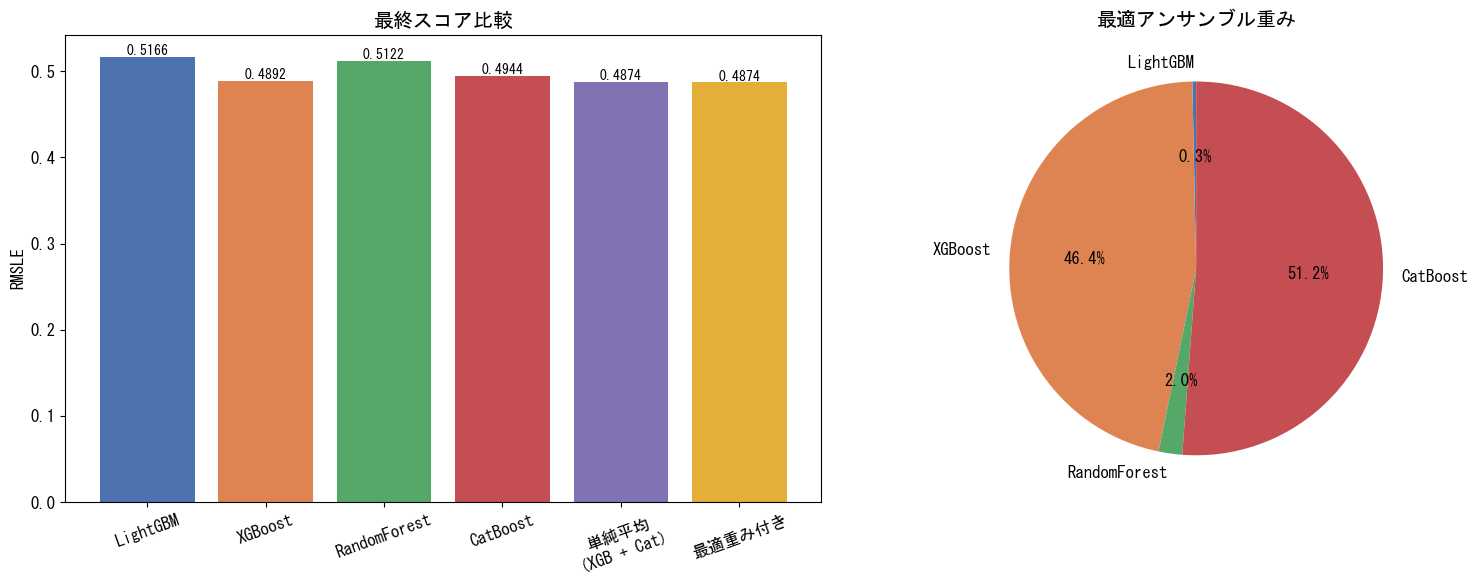

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 単体 vs アンサンブル
compare_names = []
compare_scores = []
compare_colors = []

for name in model_list:
    compare_names.append(name)
    compare_scores.append(rmsle(actual, tuned_preds[name]))
    compare_colors.append(model_colors[name])

best_simple = ens_df.iloc[0]
compare_names.append(f'単純平均\n({best_simple["組み合わせ"]})')
compare_scores.append(best_simple['RMSLE'])
compare_colors.append('#8172B3')

compare_names.append('最適重み付き')
compare_scores.append(study_w.best_value)
compare_colors.append('#E5AE38')

bars = axes[0].bar(compare_names, compare_scores, color=compare_colors)
for bar, val in zip(bars, compare_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')
axes[0].set_ylabel('RMSLE')
axes[0].set_title('最終スコア比較')
axes[0].tick_params(axis='x', rotation=20)

# 重みの可視化
axes[1].pie(list(best_weights.values()), labels=list(best_weights.keys()),
            autopct='%1.1f%%', colors=[model_colors[n] for n in best_weights], startangle=90)
axes[1].set_title('最適アンサンブル重み')

plt.tight_layout()
plt.show()

---
## 7. 最終結果まとめ

In [11]:
print('=' * 70)
print('04. 横断比較・アンサンブル — 最終結果まとめ')
print('=' * 70)

print('\n【前提条件（02で確定）】')
print(f'  学習データ期間: {settings["best_train_period"]} (start={settings["best_train_start"]})')
print(f'  NaN処理: {settings["best_nan_strategy"]}')
print(f'  Rolling構成: {settings["best_rolling_config"]}')

print('\n【単体モデル性能（チューニング済み）】')
print(f'{"モデル":<14s} {"デフォルト":>10s} {"チューニング後":>12s} {"改善幅":>8s}')
for name, r in results.items():
    default = r['score_single']
    tuned = r.get('tuned_score', default)
    print(f'{name:<14s} {default:>10.5f} {tuned:>12.5f} {default-tuned:>+8.5f}')

print('\n【アンサンブル】')
print(f'  最良単純平均: {best_simple["組み合わせ"]} (RMSLE={best_simple["RMSLE"]:.5f})')
print(f'  最適重み付き: RMSLE={study_w.best_value:.5f}')
for name, w in best_weights.items():
    print(f'    {name}: {w:.1%}')

print('\n【特徴量カテゴリ寄与度（Ablation）】')
for cat in sorted(ablation_results, key=lambda k: ablation_results[k]['degradation'], reverse=True):
    d = ablation_results[cat]['degradation']
    print(f'  {cat:14s}: 除外時悪化 +{d:.5f}')

04. 横断比較・アンサンブル — 最終結果まとめ

【前提条件（02で確定）】
  学習データ期間: 直近15ヶ月 (start=2015-12-12)
  NaN処理: NaN(デフォルト)
  Rolling構成: 現行のみ

【単体モデル性能（チューニング済み）】
モデル                 デフォルト      チューニング後      改善幅
LightGBM          0.50253      0.51664 -0.01411
XGBoost           0.48972      0.48917 +0.00055
RandomForest      0.51215      0.50698 +0.00517
CatBoost          0.49721      0.49441 +0.00280

【アンサンブル】
  最良単純平均: XGB + Cat (RMSLE=0.48739)
  最適重み付き: RMSLE=0.48738
    LightGBM: 0.3%
    XGBoost: 46.4%
    RandomForest: 2.0%
    CatBoost: 51.2%

【特徴量カテゴリ寄与度（Ablation）】
  Rolling統計量    : 除外時悪化 +0.01112
  時間/店舗属性       : 除外時悪化 +0.00475
  ラグ特徴量         : 除外時悪化 +0.00232
  ジャンル          : 除外時悪化 +-0.00043
  休業パターン        : 除外時悪化 +-0.00077
  祝日前後          : 除外時悪化 +-0.00113
  店舗統計量         : 除外時悪化 +-0.00917


In [12]:
# 中間データの保存
results_04 = {
    'best_weights': best_weights,
    'best_ensemble_score': study_w.best_value,
    'tuned_preds': tuned_preds,
    'ablation_results': ablation_results,
    'ensemble_df': ens_df,
    'confirmed_settings': settings,
}

with open(INTERMEDIATE_DIR / '04_comparison_results.pkl', 'wb') as f:
    pickle.dump(results_04, f)

print(f'中間データ保存完了: {INTERMEDIATE_DIR / "04_comparison_results.pkl"}')

中間データ保存完了: intermediate\04_comparison_results.pkl
